In [25]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

In [26]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'gamma' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)
        
max_before_tempering_is_one = max([int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1]) for idx in range(n)])



/tmp/ipykernel_55032/3919278319.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


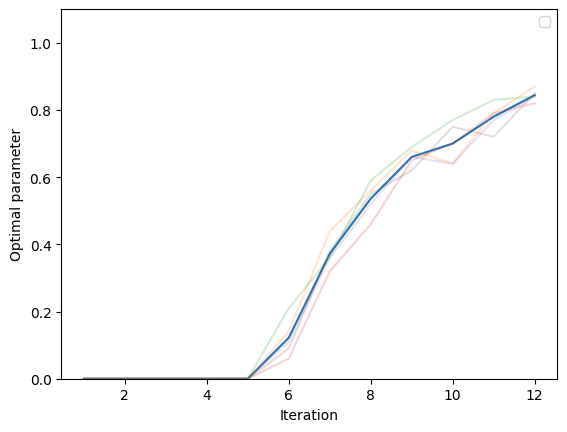

In [27]:
for idx in list_idx_ar:
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][2][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][0].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][2][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel("Optimal parameter")
plt.xlabel("Iteration")
plt.ylim(0, 1.1)
plt.legend()
plt.savefig("AR_optimal_parameter.png")

In [28]:
PKLs[0]['res'][2][:,:max_before_tempering_is_one]

Array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.14      ],
        [0.44      ],
        [0.56      ],
        [0.68      ],
        [0.64      ],
        [0.78999996],
        [0.87      ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.21      ],
        [0.35999998],
        [0.59      ],
        [0.69      ],
        [0.77      ],
        [0.83      ],
        [0.84      ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.06      ],
        [0.32      ],
        [0.45999998],
        [0.65      ],
        [0.7       ],
        [0.78999996],
        [0.82      ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.11      ],
        [0.35999998],
        [0.52      ],
        [0.65999997],
    

/tmp/ipykernel_55032/3476259838.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


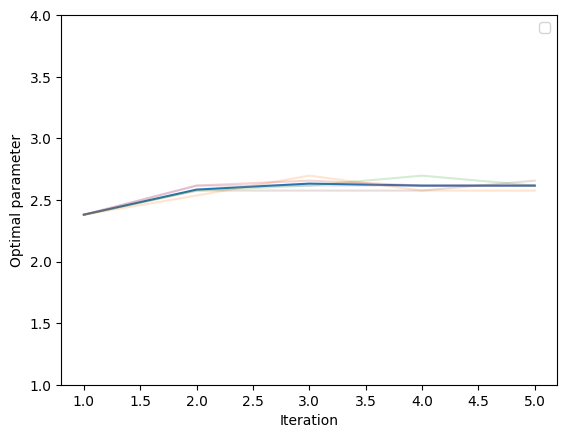

In [12]:
for idx in list_idx_rwmh:
    xaxis = range(1, max_before_tempering_is_one +1 )
    all_parameters = PKLs[idx]['res'][2][:,:max_before_tempering_is_one]
    plt.plot(xaxis, np.mean(all_parameters, axis=0))
    for run in range(PKLs[idx]['res'][0].shape[0]):
        plt.plot(xaxis, PKLs[idx]['res'][2][run,:max_before_tempering_is_one], alpha=0.2)
plt.ylabel("Optimal parameter")
plt.xlabel("Iteration")
plt.ylim(1, 4)
plt.legend()
plt.savefig("RW_optimal_parameter.png")